In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import normaltest
from scipy.stats import skew, kurtosis
import os
from tqdm import tqdm

In [3]:
df = pd.read_csv("final_dataset.csv")

In [5]:
df

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,price_20d_after,price_1y_after,return_20d_w,return_1y_w
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,15.951273,17.373795,10.092643,19.910615
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,2.464649,2.974078,-0.071369,20.583302
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,18.000000,23.020000,-18.699185,3.974711
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,726.000000,625.500000,-7.545368,-20.343840
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,6.539882,7.984721,-1.846078,19.838819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17144,2026-03-30,Purchased,"CITIZENS, INC.",CIA,Stenberg Jon,President & CEO,50000.00,4.700000,2.350000e+05,4.820000,5.730000,NaN,18.879664,NaN
17145,2026-03-30,Purchased,Sibanye Stillwater Ltd,SBSW,Carter Charles Edward,Chief Regional Officer: Amer.,10000.00,11.400000,1.140000e+05,11.140000,11.930000,NaN,7.091561,NaN
17146,2026-03-30,Purchased,TAIWAN SEMICONDUCTOR MANUFACTURING CO LTD,TSM,Lin Shyue-Shyh,VP,3000.00,54.720000,1.641600e+05,315.760529,391.423340,NaN,23.962087,NaN
17147,2026-03-30,Purchased,"Zenas BioPharma, Inc.",ZBIO,MOULDER LEON O JR,Chief Executive Officer,20000.00,18.230000,3.646000e+05,18.225000,18.010000,NaN,-1.179699,NaN


In [12]:
tickers = df["ticker"].dropna().unique()

In [7]:
len(tickers)

NameError: name 'tickers' is not defined

In [16]:
price_map = []

for t in tqdm(tickers):

    try:
        hist = yf.download(
            t,
            start="2006-01-01",
            end="2026-05-01",
            auto_adjust=True,
            progress=False
        )

        if hist is None or hist.empty:
            continue

        hist = hist.reset_index()

        # 20 sesji forward
        hist["price_3y_after"] = hist["Close"].shift(-756)

        hist["ticker"] = t

        price_map.append(hist[["ticker", "Date", "price_3y_after"]])

    except:
        continue

  1%|█▏                                                                              | 40/2791 [00:19<16:42,  2.74it/s]
1 Failed download:
['CVGW']: YFPricesMissingError('possibly delisted; no price data found  (1d 2006-01-01 -> 2026-05-01) (Yahoo error = "Data doesn\'t exist for startDate = 1136091600, endDate = 1777608000")')
  4%|██▉                                                                            | 104/2791 [00:44<16:17,  2.75it/s]
1 Failed download:
['BK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2006-01-01 -> 2026-05-01) (Yahoo error = "Data doesn\'t exist for startDate = 1136091600, endDate = 1777608000")')
  7%|█████▍                                                                         | 192/2791 [01:22<21:27,  2.02it/s]
1 Failed download:
['NFX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2006-01-01 -> 2026-05-01) (Yahoo error = "Data doesn\'t exist for startDate = 1136091600, endDate = 1777608000")')
  7%|█████▍  

In [18]:
prices = pd.concat(price_map, ignore_index=True)

if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(0)

prices = prices.rename(columns={"Date": "date"})

In [22]:
prices

Price,ticker,date,price_3y_after
0,COLB,2006-01-03,5.966242
1,COLB,2006-01-04,6.323151
2,COLB,2006-01-05,6.131380
3,COLB,2006-01-06,6.046149
4,COLB,2006-01-09,5.785125
...,...,...,...
10072361,TSM,2026-04-24,NaN
10072362,TSM,2026-04-27,NaN
10072363,TSM,2026-04-28,NaN
10072364,TSM,2026-04-29,NaN


In [20]:
df = df.merge(
    prices,
    on=["ticker", "date"],
    how="left"
)

ValueError: You are trying to merge on object and datetime64[ns] columns for key 'date'. If you wish to proceed you should use pd.concat

In [26]:
print(df.dtypes)
print(prices.dtypes)

date                object
action              object
company             object
ticker              object
name                object
title               object
shares             float64
avg_price          float64
value_usd          float64
entry_price        float64
price_20d_after    float64
price_1y_after     float64
return_20d_w       float64
return_1y_w        float64
dtype: object
Price
ticker                    object
date              datetime64[ns]
price_3y_after           float64
dtype: object


In [28]:
df["date"] = pd.to_datetime(df["date"])
prices["date"] = pd.to_datetime(prices["date"])

In [30]:
df = df.merge(
    prices,
    on=["ticker", "date"],
    how="left"
)

In [32]:
df

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,price_20d_after,price_1y_after,return_20d_w,return_1y_w,price_3y_after
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,15.951273,17.373795,10.092643,19.910615,6.323151
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,2.464649,2.974078,-0.071369,20.583302,1.585545
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,18.000000,23.020000,-18.699185,3.974711,13.380000
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,726.000000,625.500000,-7.545368,-20.343840,439.750000
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,6.539882,7.984721,-1.846078,19.838819,9.937156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17144,2026-03-30,Purchased,"CITIZENS, INC.",CIA,Stenberg Jon,President & CEO,50000.00,4.700000,2.350000e+05,4.820000,5.730000,NaN,18.879664,NaN,NaN
17145,2026-03-30,Purchased,Sibanye Stillwater Ltd,SBSW,Carter Charles Edward,Chief Regional Officer: Amer.,10000.00,11.400000,1.140000e+05,11.140000,11.930000,NaN,7.091561,NaN,NaN
17146,2026-03-30,Purchased,TAIWAN SEMICONDUCTOR MANUFACTURING CO LTD,TSM,Lin Shyue-Shyh,VP,3000.00,54.720000,1.641600e+05,315.760529,391.423340,NaN,23.962087,NaN,NaN
17147,2026-03-30,Purchased,"Zenas BioPharma, Inc.",ZBIO,MOULDER LEON O JR,Chief Executive Officer,20000.00,18.230000,3.646000e+05,18.225000,18.010000,NaN,-1.179699,NaN,NaN


In [34]:
df.describe()

,date,shares,avg_price,value_usd,entry_price,price_20d_after,price_1y_after,return_20d_w,return_1y_w,price_3y_after
count,17149,1.714900e+04,1.714900e+04,1.714900e+04,1.714900e+04,1.714900e+04,1.582100e+04,17149.000000,15821.000000,1.326200e+04
mean,2017-12-05 11:38:02.512099840,7.373168e+06,4.444187e+03,9.727382e+08,1.032000e+07,1.017354e+07,8.875052e+06,3.311416,17.047891,5.730434e+06
min,2006-01-04 00:00:00,4.000000e+00,1.000000e-02,1.000000e+05,1.000000e+00,3.000000e-01,1.000000e-04,-41.046908,-86.056050,1.000000e-05
25%,2013-08-09 00:00:00,8.000000e+03,8.440000e+00,1.499750e+05,6.842105e+00,6.916628e+00,7.288263e+00,-3.688053,-17.966903,7.638952e+00
50%,2018-12-20 00:00:00,1.833700e+04,1.700000e+01,2.499807e+05,1.389952e+01,1.425432e+01,1.455323e+01,2.306210,7.705830,1.582242e+01
75%,2022-09-06 00:00:00,5.000000e+04,3.398000e+01,5.568420e+05,3.097269e+01,3.188000e+01,3.205470e+01,9.348302,37.024608,3.415438e+01
max,2026-03-31 00:00:00,1.227720e+11,6.451255e+07,5.169712e+12,5.823797e+10,5.515909e+10,5.016771e+10,58.933619,292.012986,2.618010e+10
std,NaN,9.375275e+08,4.933471e+05,5.508572e+10,7.000718e+08,6.867728e+08,5.988316e+08,14.689006,61.402645,3.613977e+08


In [36]:
df["return_3y"] = (df["price_3y_after"] / df["entry_price"] - 1) * 100

In [38]:
df

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,price_20d_after,price_1y_after,return_20d_w,return_1y_w,price_3y_after,return_3y
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,15.951273,17.373795,10.092643,19.910615,6.323151,-56.358821
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,2.464649,2.974078,-0.071369,20.583302,1.585545,-35.714442
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,18.000000,23.020000,-18.699185,3.974711,13.380000,-39.566393
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,726.000000,625.500000,-7.545368,-20.343840,439.750000,-43.998727
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,6.539882,7.984721,-1.846078,19.838819,9.937156,49.141964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17144,2026-03-30,Purchased,"CITIZENS, INC.",CIA,Stenberg Jon,President & CEO,50000.00,4.700000,2.350000e+05,4.820000,5.730000,NaN,18.879664,NaN,NaN,NaN
17145,2026-03-30,Purchased,Sibanye Stillwater Ltd,SBSW,Carter Charles Edward,Chief Regional Officer: Amer.,10000.00,11.400000,1.140000e+05,11.140000,11.930000,NaN,7.091561,NaN,NaN,NaN
17146,2026-03-30,Purchased,TAIWAN SEMICONDUCTOR MANUFACTURING CO LTD,TSM,Lin Shyue-Shyh,VP,3000.00,54.720000,1.641600e+05,315.760529,391.423340,NaN,23.962087,NaN,NaN,NaN
17147,2026-03-30,Purchased,"Zenas BioPharma, Inc.",ZBIO,MOULDER LEON O JR,Chief Executive Officer,20000.00,18.230000,3.646000e+05,18.225000,18.010000,NaN,-1.179699,NaN,NaN,NaN


In [40]:
df.describe()

,date,shares,avg_price,value_usd,entry_price,price_20d_after,price_1y_after,return_20d_w,return_1y_w,price_3y_after,return_3y
count,17149,1.714900e+04,1.714900e+04,1.714900e+04,1.714900e+04,1.714900e+04,1.582100e+04,17149.000000,15821.000000,1.326200e+04,13262.000000
mean,2017-12-05 11:38:02.512099840,7.373168e+06,4.444187e+03,9.727382e+08,1.032000e+07,1.017354e+07,8.875052e+06,3.311416,17.047891,5.730434e+06,214.308834
min,2006-01-04 00:00:00,4.000000e+00,1.000000e-02,1.000000e+05,1.000000e+00,3.000000e-01,1.000000e-04,-41.046908,-86.056050,1.000000e-05,-99.999913
25%,2013-08-09 00:00:00,8.000000e+03,8.440000e+00,1.499750e+05,6.842105e+00,6.916628e+00,7.288263e+00,-3.688053,-17.966903,7.638952e+00,-23.876593
50%,2018-12-20 00:00:00,1.833700e+04,1.700000e+01,2.499807e+05,1.389952e+01,1.425432e+01,1.455323e+01,2.306210,7.705830,1.582242e+01,23.782158
75%,2022-09-06 00:00:00,5.000000e+04,3.398000e+01,5.568420e+05,3.097269e+01,3.188000e+01,3.205470e+01,9.348302,37.024608,3.415438e+01,73.268184
max,2026-03-31 00:00:00,1.227720e+11,6.451255e+07,5.169712e+12,5.823797e+10,5.515909e+10,5.016771e+10,58.933619,292.012986,2.618010e+10,266087.045490
std,NaN,9.375275e+08,4.933471e+05,5.508572e+10,7.000718e+08,6.867728e+08,5.988316e+08,14.689006,61.402645,3.613977e+08,4444.552006


In [42]:
df["return_3y"].quantile([
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

0.900      158.940745
0.950      241.806903
0.990      660.358648
0.995     1234.924399
0.999    77376.711946
Name: return_3y, dtype: float64

In [44]:
lower = df["return_3y"].quantile(0.01)
upper = df["return_3y"].quantile(0.99)

In [46]:
lower

-97.36481481481482

In [48]:
upper

660.3586479340158

In [50]:
df["return_3y_w"] = df["return_3y"].clip(lower, upper)

In [52]:
df

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,price_20d_after,price_1y_after,return_20d_w,return_1y_w,price_3y_after,return_3y,return_3y_w
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,15.951273,17.373795,10.092643,19.910615,6.323151,-56.358821,-56.358821
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,2.464649,2.974078,-0.071369,20.583302,1.585545,-35.714442,-35.714442
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,18.000000,23.020000,-18.699185,3.974711,13.380000,-39.566393,-39.566393
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,726.000000,625.500000,-7.545368,-20.343840,439.750000,-43.998727,-43.998727
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,6.539882,7.984721,-1.846078,19.838819,9.937156,49.141964,49.141964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17144,2026-03-30,Purchased,"CITIZENS, INC.",CIA,Stenberg Jon,President & CEO,50000.00,4.700000,2.350000e+05,4.820000,5.730000,NaN,18.879664,NaN,NaN,NaN,NaN
17145,2026-03-30,Purchased,Sibanye Stillwater Ltd,SBSW,Carter Charles Edward,Chief Regional Officer: Amer.,10000.00,11.400000,1.140000e+05,11.140000,11.930000,NaN,7.091561,NaN,NaN,NaN,NaN
17146,2026-03-30,Purchased,TAIWAN SEMICONDUCTOR MANUFACTURING CO LTD,TSM,Lin Shyue-Shyh,VP,3000.00,54.720000,1.641600e+05,315.760529,391.423340,NaN,23.962087,NaN,NaN,NaN,NaN
17147,2026-03-30,Purchased,"Zenas BioPharma, Inc.",ZBIO,MOULDER LEON O JR,Chief Executive Officer,20000.00,18.230000,3.646000e+05,18.225000,18.010000,NaN,-1.179699,NaN,NaN,NaN,NaN


In [54]:
df.describe()

,date,shares,avg_price,value_usd,entry_price,price_20d_after,price_1y_after,return_20d_w,return_1y_w,price_3y_after,return_3y,return_3y_w
count,17149,1.714900e+04,1.714900e+04,1.714900e+04,1.714900e+04,1.714900e+04,1.582100e+04,17149.000000,15821.000000,1.326200e+04,13262.000000,13262.000000
mean,2017-12-05 11:38:02.512099840,7.373168e+06,4.444187e+03,9.727382e+08,1.032000e+07,1.017354e+07,8.875052e+06,3.311416,17.047891,5.730434e+06,214.308834,44.336098
min,2006-01-04 00:00:00,4.000000e+00,1.000000e-02,1.000000e+05,1.000000e+00,3.000000e-01,1.000000e-04,-41.046908,-86.056050,1.000000e-05,-99.999913,-97.364815
25%,2013-08-09 00:00:00,8.000000e+03,8.440000e+00,1.499750e+05,6.842105e+00,6.916628e+00,7.288263e+00,-3.688053,-17.966903,7.638952e+00,-23.876593,-23.876593
50%,2018-12-20 00:00:00,1.833700e+04,1.700000e+01,2.499807e+05,1.389952e+01,1.425432e+01,1.455323e+01,2.306210,7.705830,1.582242e+01,23.782158,23.782158
75%,2022-09-06 00:00:00,5.000000e+04,3.398000e+01,5.568420e+05,3.097269e+01,3.188000e+01,3.205470e+01,9.348302,37.024608,3.415438e+01,73.268184,73.268184
max,2026-03-31 00:00:00,1.227720e+11,6.451255e+07,5.169712e+12,5.823797e+10,5.515909e+10,5.016771e+10,58.933619,292.012986,2.618010e+10,266087.045490,660.358648
std,NaN,9.375275e+08,4.933471e+05,5.508572e+10,7.000718e+08,6.867728e+08,5.988316e+08,14.689006,61.402645,3.613977e+08,4444.552006,115.405598


In [56]:
stats = pd.DataFrame({
    "3 lata": [
        df["return_3y_w"].count(),
        df["return_3y_w"].mean(),
        df["return_3y_w"].median(),
        df["return_3y_w"].std(),
        df["return_3y_w"].dropna().gt(0).mean() * 100
    ]
}, index=[
    "Liczba obserwacji",
    "Średnia stopa zwrotu",
    "Mediana stopy zwrotu",
    "Odchylenie standardowe",
    "Hit rate"
])

stats.iloc[1:] = stats.iloc[1:].round(2)

print(stats)

                          3 lata
Liczba obserwacji       13262.00
Średnia stopa zwrotu       44.34
Mediana stopy zwrotu       23.78
Odchylenie standardowe    115.41
Hit rate                   63.52


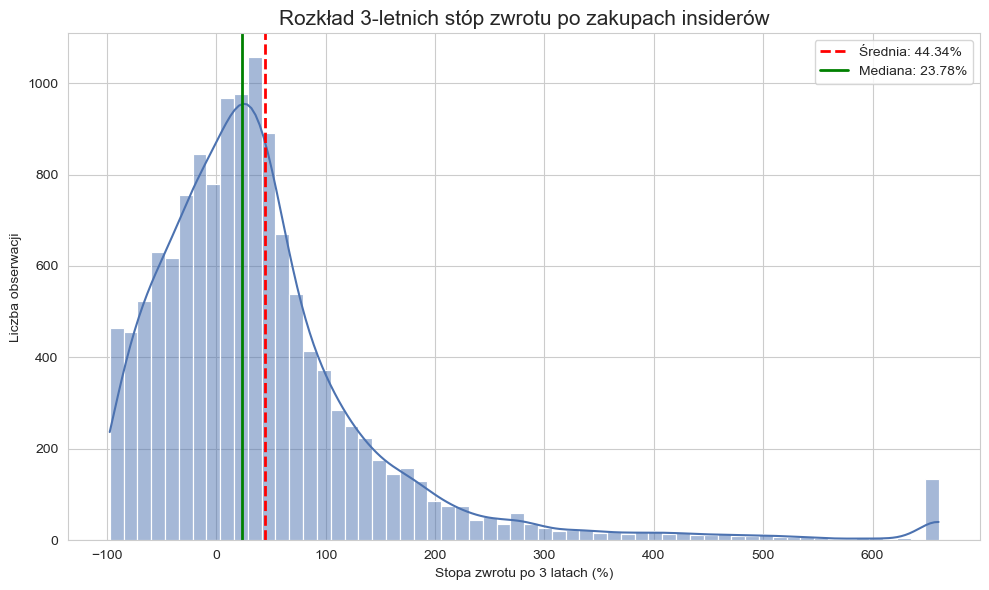

In [58]:
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(
    df["return_3y_w"],
    bins=60,
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    ax=ax
)

mean = df["return_3y_w"].mean()
median = df["return_3y_w"].median()

ax.axvline(mean, color="red", linestyle="--", linewidth=2,
           label=f"Średnia: {mean:.2f}%")

ax.axvline(median, color="green", linestyle="-", linewidth=2,
           label=f"Mediana: {median:.2f}%")

ax.set_title("Rozkład 3-letnich stóp zwrotu po zakupach insiderów", fontsize=15)
ax.set_xlabel("Stopa zwrotu po 3 latach (%)")
ax.set_ylabel("Liczba obserwacji")

ax.legend()

plt.tight_layout()
plt.show()

In [66]:
stat3y, p3y = normaltest(df["return_3y_w"].dropna())
print(f"3 lata : stat={stat3y:.2f}, p={p3y:.5g}")

3 lata : stat=7408.41, p=0


In [60]:
for col in ["return_3y_w"]:
    x = df[col].dropna()

    print(col)
    print("N =", len(x))
    print("Skewness:", skew(x))
    print("Excess kurtosis:", kurtosis(x))

return_3y_w
N = 13262
Skewness: 2.580429517899651
Excess kurtosis: 9.57991138966893


In [74]:
bins = [-float("inf"), -50, -25, 0, 25, 50, 100, float("inf")]

labels = [
    "< -50%",
    "-50% do -25%",
    "-25% do 0%",
    "0% do 25%",
    "25% do 50%",
    "50% do 100%",
    "> 100%"
]

In [76]:
dist_3y = (
    pd.cut(
        df["return_3y_w"].dropna(),
        bins=bins,
        labels=labels
    )
    .value_counts()
    .sort_index()
)

dist_3y_pct = (dist_3y / dist_3y.sum() * 100).round(2)

print(pd.DataFrame({
    "Liczba obserwacji": dist_3y,
    "Udział": dist_3y_pct.astype(str) + "%"
}))

              Liczba obserwacji  Udział
return_3y_w                            
< -50%                     1931  14.56%
-50% do -25%               1301   9.81%
-25% do 0%                 1606  12.11%
0% do 25%                  1856  13.99%
25% do 50%                 2005  15.12%
50% do 100%                2126  16.03%
> 100%                     2437  18.38%


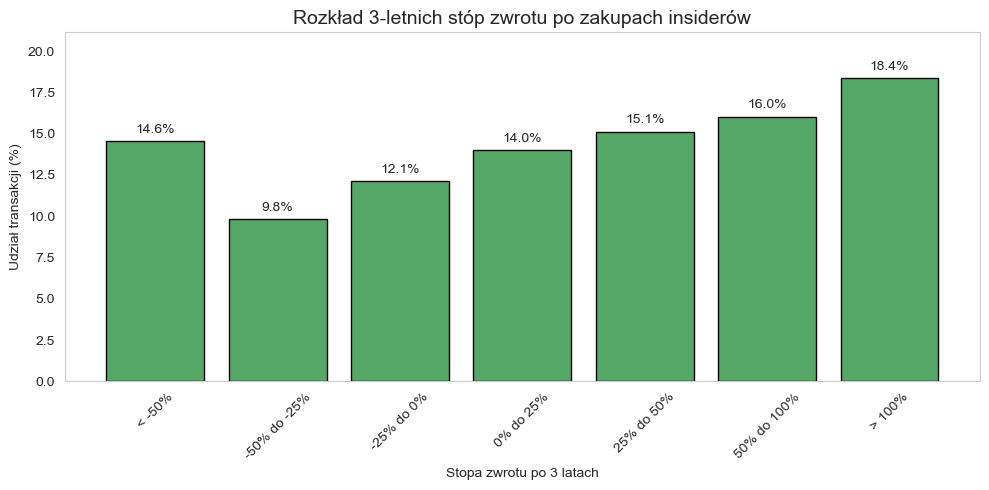

In [80]:
bins_3y = [
    -float("inf"),
    -50,
    -25,
    0,
    25,
    50,
    100,
    float("inf")
]

labels_3y = [
    "< -50%",
    "-50% do -25%",
    "-25% do 0%",
    "0% do 25%",
    "25% do 50%",
    "50% do 100%",
    "> 100%"
]


dist_3y = (
    pd.cut(
        df["return_3y_w"].dropna(),
        bins=bins_3y,
        labels=labels_3y
    )
    .value_counts()
    .sort_index()
)

dist_3y_pct = dist_3y / dist_3y.sum() * 100


plt.figure(figsize=(10,5))

bars = plt.bar(
    dist_3y_pct.index,
    dist_3y_pct.values,
    color="#55A868",
    edgecolor="black"
)

plt.title(
    "Rozkład 3-letnich stóp zwrotu po zakupach insiderów",
    fontsize=14
)

plt.xlabel("Stopa zwrotu po 3 latach")
plt.ylabel("Udział transakcji (%)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        fontsize=10
    )

plt.ylim(0, max(dist_3y_pct.values)*1.15)

plt.grid(False)
plt.tight_layout()
plt.show()

In [82]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.to_period("M")

In [84]:
yearly_stats_3y = df.groupby("year").agg(
    mean_return=("return_3y_w", "mean"),
    median_return=("return_3y_w", "median"),
    hit_rate=("return_3y_w", lambda x: (x.dropna() > 0).mean()),
    n_obs=("return_3y_w", "count")
).reset_index()

In [92]:
yearly_stats_3y = yearly_stats_3y[
    (yearly_stats_3y["year"] >= 2006) &
    (yearly_stats_3y["year"] <= 2023)
]

In [94]:
yearly_stats_3y

,year,mean_return,median_return,hit_rate,n_obs
0,2006,-17.474833,-28.237636,0.224586,423
1,2007,16.503246,-1.250799,0.495697,581
2,2008,81.374376,47.639860,0.752688,837
3,2009,138.069836,98.509052,0.871314,373
4,2010,48.157366,31.288053,0.849576,472
5,2011,63.400986,54.327965,0.762128,639
6,2012,99.821280,72.896220,0.796791,561
7,2013,21.922831,28.320887,0.731884,552
8,2014,17.081509,9.102910,0.581709,667
9,2015,33.579444,33.457285,0.733126,963


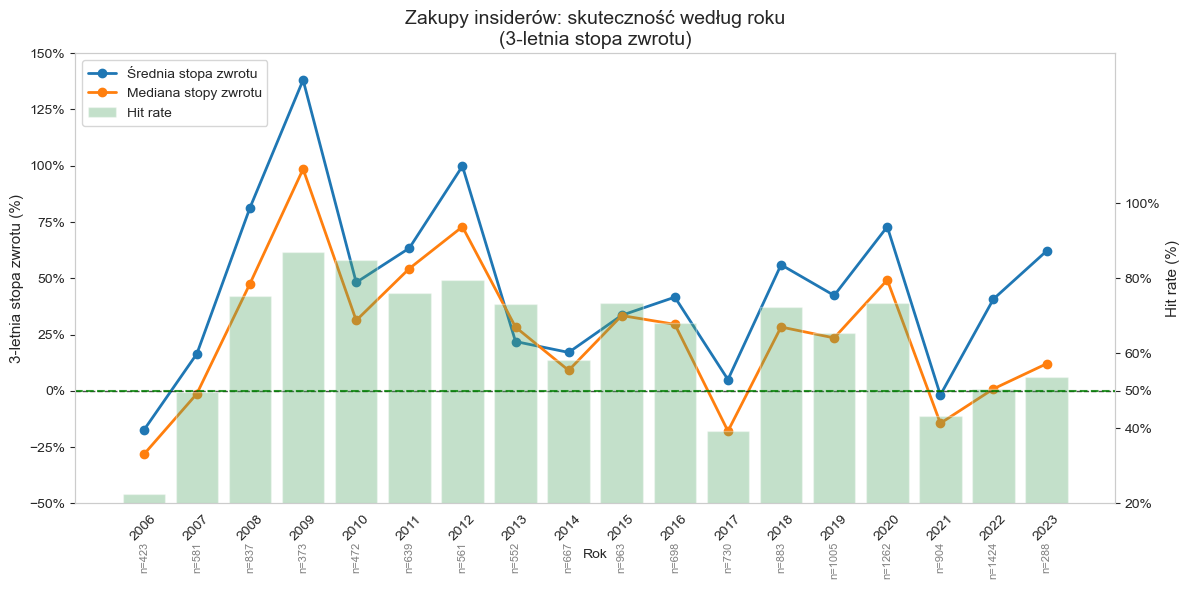

In [108]:
plt.rcParams["axes.grid"] = False


# ograniczenie okresu 2006-2023
plot_data = yearly_stats_3y[
    (yearly_stats_3y["year"] >= 2006) &
    (yearly_stats_3y["year"] <= 2023)
]


fig, ax1 = plt.subplots(figsize=(12,6))


# ==========================
# LEWA OŚ - ROCZNE STOPY ZWROTU
# ==========================

ax1.plot(
    plot_data["year"],
    plot_data["mean_return"],
    color="#1f77b4",
    marker="o",
    linewidth=2,
    label="Średnia stopa zwrotu"
)

ax1.plot(
    plot_data["year"],
    plot_data["median_return"],
    color="#ff7f0e",
    marker="o",
    linewidth=2,
    label="Mediana stopy zwrotu"
)


# poziom 0% zwrotu
ax1.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


ax1.set_ylabel(
    "3-letnia stopa zwrotu (%)",
    fontsize=11
)

ax1.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


# zakres lewej osi
# 0% = 50% hit rate
ax1.set_ylim(-50, 150)



# ==========================
# PRAWA OŚ - HIT RATE
# ==========================

ax2 = ax1.twinx()


ax2.bar(
    plot_data["year"],
    plot_data["hit_rate"] * 100,
    color="#55A868",
    alpha=0.35,
    width=0.8,
    label="Hit rate"
)


# poziom 50% skuteczności
ax2.axhline(
    50,
    color="green",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)


ax2.set_ylabel(
    "Hit rate (%)",
    fontsize=11
)

ax2.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


# zakres prawej osi
ax2.set_ylim(20, 140)

ax2.set_yticks([20, 40, 50, 60, 80, 100])
ax2.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)

# ==========================
# FORMATOWANIE
# ==========================

ax1.set_title(
    "Zakupy insiderów: skuteczność według roku\n"
    "(3-letnia stopa zwrotu)",
    fontsize=14
)


ax1.set_xlabel(
    "Rok"
)


ax1.set_xticks(
    plot_data["year"]
)


ax1.tick_params(
    axis="x",
    rotation=45
)



# liczba obserwacji
for x, n in zip(
    plot_data["year"],
    plot_data["n_obs"]
):
    ax1.text(
        x,
        -67,
        f"n={n}",
        ha="center",
        va="top",
        fontsize=8,
        color="gray",
        rotation=90
    )



# ==========================
# LEGENDA
# ==========================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()


ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)



# brak siatki
ax1.grid(False)
ax2.grid(False)


plt.tight_layout()
plt.show()

In [110]:
yearly_insider = df.groupby("year").agg(
    insider_volume_usd=("value_usd", "sum"),
    n_transactions=("value_usd", "count"),
    median_transaction=("value_usd", "median")
).reset_index()

In [112]:
yearly_insider

,year,insider_volume_usd,n_transactions,median_transaction
0,2006,1.426666e+11,425,258013.370
1,2007,6.318446e+08,587,244200.000
2,2008,4.180093e+12,843,256870.000
3,2009,4.289718e+08,384,214975.000
4,2010,9.488566e+11,478,270810.705
5,2011,3.250260e+10,672,221332.500
6,2012,8.819278e+11,575,199994.840
7,2013,5.256671e+12,555,226765.000
8,2014,3.968670e+08,675,240000.000
9,2015,9.210856e+08,994,202470.000


In [114]:
yearly_insider["log_insider_volume"] = np.log10(
    yearly_insider["insider_volume_usd"]
)

In [116]:
analysis_year = yearly_stats_3y.merge(
    yearly_insider,
    on="year",
    how="left"
)

In [118]:
analysis_year

,year,mean_return,median_return,hit_rate,n_obs,insider_volume_usd,n_transactions,median_transaction,log_insider_volume
0,2006,-17.474833,-28.237636,0.224586,423,1.426666e+11,425,258013.370,11.154322
1,2007,16.503246,-1.250799,0.495697,581,6.318446e+08,587,244200.000,8.800610
2,2008,81.374376,47.639860,0.752688,837,4.180093e+12,843,256870.000,12.621186
3,2009,138.069836,98.509052,0.871314,373,4.289718e+08,384,214975.000,8.632429
4,2010,48.157366,31.288053,0.849576,472,9.488566e+11,478,270810.705,11.977201
5,2011,63.400986,54.327965,0.762128,639,3.250260e+10,672,221332.500,10.511918
6,2012,99.821280,72.896220,0.796791,561,8.819278e+11,575,199994.840,11.945433
7,2013,21.922831,28.320887,0.731884,552,5.256671e+12,555,226765.000,12.720711
8,2014,17.081509,9.102910,0.581709,667,3.968670e+08,675,240000.000,8.598645
9,2015,33.579444,33.457285,0.733126,963,9.210856e+08,994,202470.000,8.964300


In [120]:
from scipy.stats import pearsonr, spearmanr

cols = [
    "log_insider_volume",
    "mean_return",
    "median_return",
    "hit_rate"
]

results = []

for x in ["mean_return", "median_return", "hit_rate"]:
    
    # Pearson
    pearson_r, pearson_p = pearsonr(
        analysis_year["log_insider_volume"],
        analysis_year[x]
    )
    
    # Spearman
    spearman_r, spearman_p = spearmanr(
        analysis_year["log_insider_volume"],
        analysis_year[x]
    )
    
    results.append({
        "zmienna": x,
        "Pearson r": pearson_r,
        "Pearson p": pearson_p,
        "Spearman rho": spearman_r,
        "Spearman p": spearman_p
    })

correlation_results = pd.DataFrame(results)

correlation_results

,zmienna,Pearson r,Pearson p,Spearman rho,Spearman p
0,mean_return,-0.125138,0.620776,-0.038184,0.880430
1,median_return,-0.119001,0.638133,-0.093911,0.710899
2,hit_rate,-0.023618,0.925887,-0.001032,0.996757


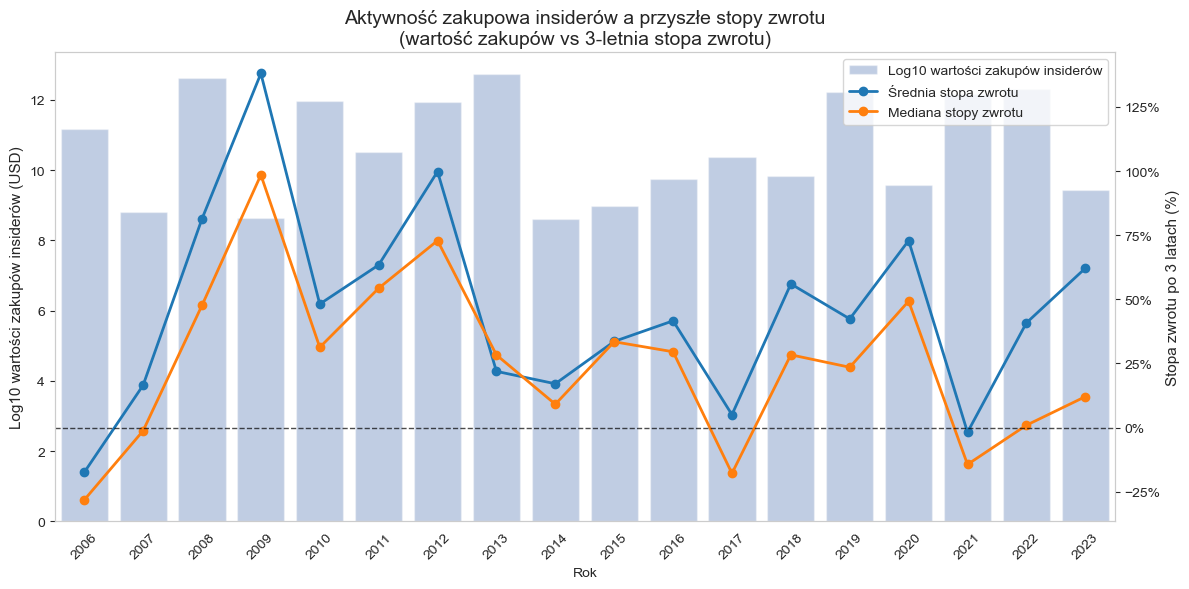

In [126]:
plt.rcParams["axes.grid"] = False


fig, ax1 = plt.subplots(figsize=(12,6))


# ==========================
# LEWA OŚ - LOG INSIDER VOLUME
# ==========================

bars = ax1.bar(
    analysis_year["year"],
    analysis_year["log_insider_volume"],
    color="#4C72B0",
    alpha=0.35,
    width=0.8,
    label="Log10 wartości zakupów insiderów"
)

ax1.set_ylabel(
    "Log10 wartości zakupów insiderów (USD)",
    fontsize=11
)


# ==========================
# PRAWA OŚ - STOPY ZWROTU
# ==========================

ax2 = ax1.twinx()


ax2.plot(
    analysis_year["year"],
    analysis_year["mean_return"],
    color="#1f77b4",
    marker="o",
    linewidth=2,
    label="Średnia stopa zwrotu"
)


ax2.plot(
    analysis_year["year"],
    analysis_year["median_return"],
    color="#ff7f0e",
    marker="o",
    linewidth=2,
    label="Mediana stopy zwrotu"
)


# poziom 0% zwrotu
ax2.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


ax2.set_ylabel(
    "Stopa zwrotu po 3 latach (%)",
    fontsize=11
)

ax2.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


# zakres lat
ax1.set_xlim(
    analysis_year["year"].min() - 0.5,
    analysis_year["year"].max() + 0.5
)



ax1.set_xticks(
    analysis_year["year"]
)

ax1.tick_params(
    axis="x",
    rotation=45
)



# ==========================
# FORMATOWANIE
# ==========================

ax1.set_xlabel(
    "Rok"
)


ax1.set_title(
    "Aktywność zakupowa insiderów a przyszłe stopy zwrotu\n"
    "(wartość zakupów vs 3-letnia stopa zwrotu)",
    fontsize=14
)


# wspólna legenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)


# brak siatki
ax1.grid(False)
ax2.grid(False)


plt.tight_layout()
plt.show()

In [130]:
from scipy.stats import spearmanr


corr_data = df[
    [
        "value_usd",
        "return_3y_w"
    ]
].dropna()


spearman_corr, p_value = spearmanr(
    corr_data["value_usd"],
    corr_data["return_3y_w"]
)


print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"N observations: {len(corr_data)}")

Spearman correlation: -0.0396
p-value: 0.000005
N observations: 13262


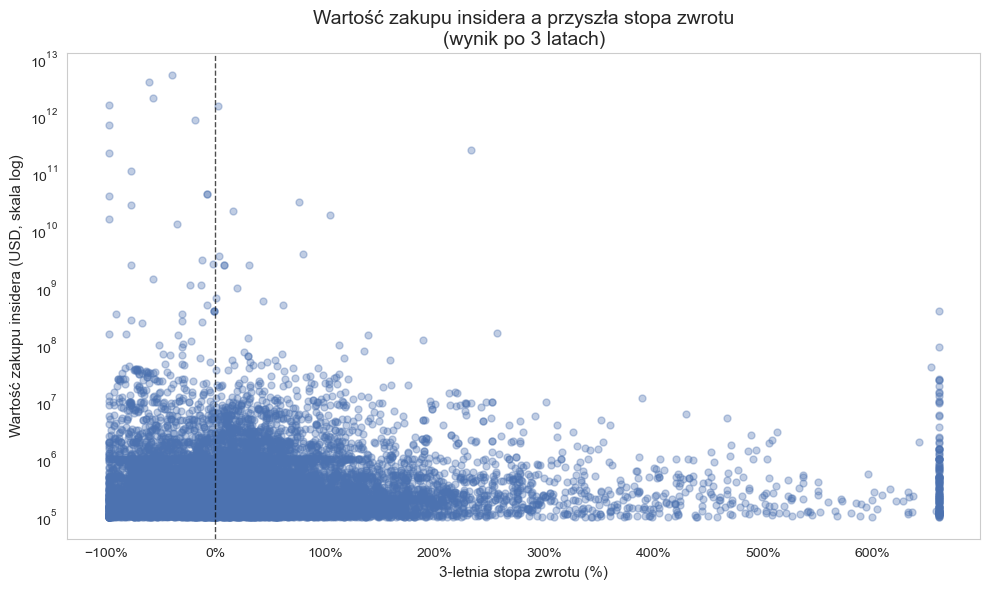

In [132]:
plot_data = df[
    [
        "value_usd",
        "return_3y_w",
        "year"
    ]
].dropna()


fig, ax = plt.subplots(figsize=(10,6))


scatter = ax.scatter(
    plot_data["return_3y_w"],
    plot_data["value_usd"],
    alpha=0.35,
    s=25,
    color="#4C72B0"
)


# skala logarytmiczna dla wartości zakupu
ax.set_yscale("log")


# formatowanie osi X jako %
ax.xaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.set_xlabel(
    "3-letnia stopa zwrotu (%)",
    fontsize=11
)


ax.set_ylabel(
    "Wartość zakupu insidera (USD, skala log)",
    fontsize=11
)


ax.set_title(
    "Wartość zakupu insidera a przyszła stopa zwrotu\n"
    "(wynik po 3 latach)",
    fontsize=14
)


# linia 0% zwrotu
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


ax.grid(False)


plt.tight_layout()
plt.show()

In [134]:
df_test = df[
    [
        "value_usd",
        "return_3y_w"
    ]
].dropna()


df_test["purchase_size_group"] = pd.qcut(
    df_test["value_usd"],
    5,
    labels=[
        "Q1 najmniejsze",
        "Q2",
        "Q3",
        "Q4",
        "Q5 największe"
    ]
)


quartile_results = df_test.groupby(
    "purchase_size_group"
).agg(
    n=("return_3y_w","count"),
    mean_return=("return_3y_w","mean"),
    median_return=("return_3y_w","median"),
    hit_rate=("return_3y_w", lambda x: (x>0).mean())
)

quartile_results

C:\Users\lukas\AppData\Local\Temp\ipykernel_12608\1768485105.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartile_results = df_test.groupby(


,n,mean_return,median_return,hit_rate
purchase_size_group,,,,
Q1 najmniejsze,2653,46.451729,28.905480,0.649453
Q2,2652,50.059847,29.326877,0.654977
Q3,2652,45.141454,23.603656,0.628959
Q4,2652,41.837647,19.565159,0.617270
Q5 największe,2653,38.191334,19.245724,0.625330


In [136]:
sp500 = yf.download("^GSPC", start="2005-01-01", end="2026-03-31", progress=False, auto_adjust=True)

sp500 = sp500.reset_index()

sp500['year'] = sp500['Date'].dt.year

annual_close = sp500.groupby('year')['Close'].last().sort_index()
sp500_annual_return = annual_close.pct_change().dropna().reset_index()
sp500_annual_return.columns = ['year', 'sp500_annual_return']

sp500_annual_return

,year,sp500_annual_return
0,2006,0.136194
1,2007,0.035296
2,2008,-0.384858
3,2009,0.234542
4,2010,0.127827
5,2011,-0.000032
6,2012,0.134057
7,2013,0.296012
8,2014,0.113906
9,2015,-0.007266


In [138]:
sp500 = sp500.copy()

sp500.columns = sp500.columns.get_level_values(0)

sp500 = sp500[
    sp500["Date"] != "Ticker"
].copy()

sp500["Date"] = pd.to_datetime(
    sp500["Date"]
)

In [140]:
print(sp500.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'year'], dtype='object', name='Price')


In [142]:
sp500["sp500_return_3y"] = (
    (
        sp500["Close"].shift(-756)
        /
        sp500["Close"]
        - 1
    )
    * 100
)

In [144]:
df_market_3y = df.merge(
    sp500[
        [
            "Date",
            "Close",
            "sp500_return_3y"
        ]
    ],
    left_on="date",
    right_on="Date",
    how="left"
)

In [146]:
df_market_3y["abnormal_return_3y"] = (
    df_market_3y["return_3y_w"]
    -
    df_market_3y["sp500_return_3y"]
)

In [150]:
comparison_3y = pd.DataFrame({
    "Insider stocks": [
        df_market_3y["return_3y_w"].mean()
    ],
    "S&P500": [
        df_market_3y["sp500_return_3y"].mean()
    ],
    "Abnormal return": [
        df_market_3y["abnormal_return_3y"].mean()
    ]
})

comparison_3y

,Insider stocks,S&P500,Abnormal return
0,44.336098,35.892335,8.454912


In [152]:
abnormal_hit_rate_3y = (
    df_market_3y["abnormal_return_3y"]
    .dropna()
    .gt(0)
    .mean()
)

print(
    f"Abnormal return hit rate: {abnormal_hit_rate_3y:.2%}"
)

Abnormal return hit rate: 44.91%


In [154]:
df_market_3y

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,...,return_1y_w,price_3y_after,return_3y,return_3y_w,year,month,Date,Close,sp500_return_3y,abnormal_return_3y
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,...,19.910615,6.323151,-56.358821,-56.358821,2006,2006-01,2006-01-04,1273.459961,-26.601539,-29.757282
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,...,20.583302,1.585545,-35.714442,-35.714442,2006,2006-01,2006-01-09,1290.150024,-30.988648,-4.725795
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,...,3.974711,13.380000,-39.566393,-39.566393,2006,2006-01,2006-01-13,1287.609985,-34.472395,-5.093999
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,...,-20.343840,439.750000,-43.998727,-43.998727,2006,2006-01,2006-01-13,1287.609985,-34.472395,-9.526332
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,...,19.838819,9.937156,49.141964,49.141964,2006,2006-01,2006-01-17,1282.930054,-33.736060,82.878025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17144,2026-03-30,Purchased,"CITIZENS, INC.",CIA,Stenberg Jon,President & CEO,50000.00,4.700000,2.350000e+05,4.820000,...,NaN,NaN,NaN,NaN,2026,2026-03,2026-03-30,6343.720215,NaN,NaN
17145,2026-03-30,Purchased,Sibanye Stillwater Ltd,SBSW,Carter Charles Edward,Chief Regional Officer: Amer.,10000.00,11.400000,1.140000e+05,11.140000,...,NaN,NaN,NaN,NaN,2026,2026-03,2026-03-30,6343.720215,NaN,NaN
17146,2026-03-30,Purchased,TAIWAN SEMICONDUCTOR MANUFACTURING CO LTD,TSM,Lin Shyue-Shyh,VP,3000.00,54.720000,1.641600e+05,315.760529,...,NaN,NaN,NaN,NaN,2026,2026-03,2026-03-30,6343.720215,NaN,NaN
17147,2026-03-30,Purchased,"Zenas BioPharma, Inc.",ZBIO,MOULDER LEON O JR,Chief Executive Officer,20000.00,18.230000,3.646000e+05,18.225000,...,NaN,NaN,NaN,NaN,2026,2026-03,2026-03-30,6343.720215,NaN,NaN


In [156]:
abnormal_3y_yearly = df_market_3y.groupby("year").agg(
    mean_abnormal_return=("abnormal_return_3y", "mean"),
    median_abnormal_return=("abnormal_return_3y", "median"),
    hit_rate=("abnormal_return_3y", lambda x: (x.dropna() > 0).mean()),
    n_obs=("abnormal_return_3y", "count")
).reset_index()


abnormal_3y_yearly = abnormal_3y_yearly[
    (abnormal_3y_yearly["year"] >= 2006) &
    (abnormal_3y_yearly["year"] <= 2023)
]

In [160]:
abnormal_3y_yearly

,year,mean_abnormal_return,median_abnormal_return,hit_rate,n_obs
0,2006,8.868343,-0.635753,0.491726,423
1,2007,38.405510,22.663718,0.640275,581
2,2008,70.454637,43.479755,0.703704,837
3,2009,80.969037,37.955013,0.691689,373
4,2010,1.706993,-15.118493,0.391949,472
5,2011,5.380244,-0.873494,0.492958,639
6,2012,49.880459,19.738109,0.607843,561
7,2013,-5.237536,-0.121329,0.498188,552
8,2014,-10.125519,-18.425750,0.358321,667
9,2015,-0.590212,1.146424,0.523364,963


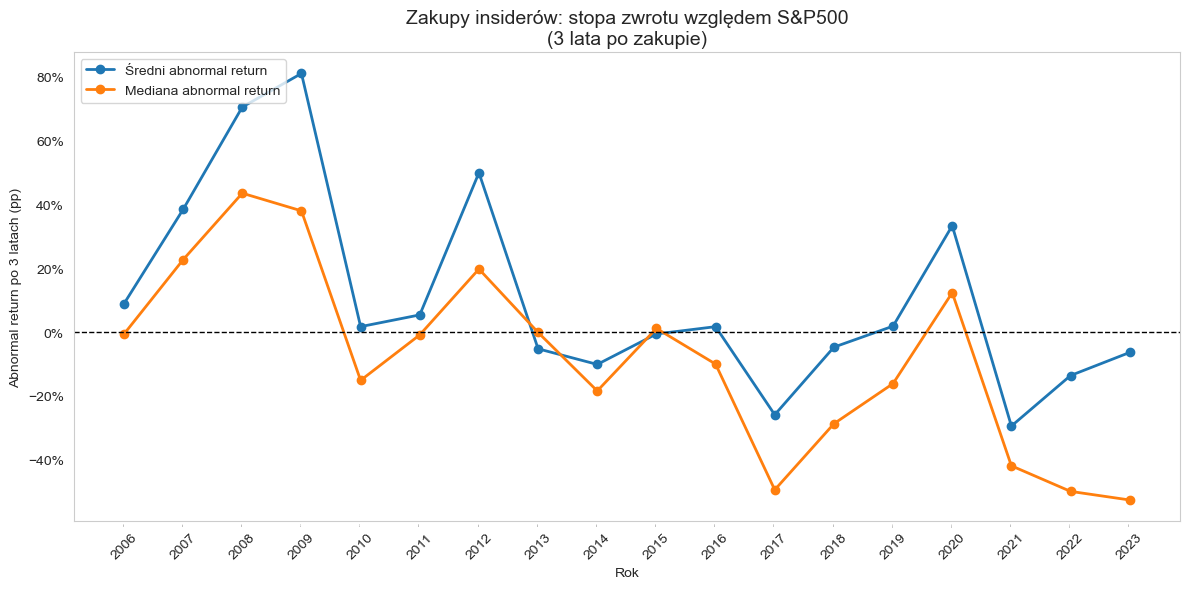

In [158]:
fig, ax = plt.subplots(figsize=(12,6))


ax.plot(
    abnormal_3y_yearly["year"],
    abnormal_3y_yearly["mean_abnormal_return"],
    color="#1f77b4",
    marker="o",
    linewidth=2,
    label="Średni abnormal return"
)


ax.plot(
    abnormal_3y_yearly["year"],
    abnormal_3y_yearly["median_abnormal_return"],
    color="#ff7f0e",
    marker="o",
    linewidth=2,
    label="Mediana abnormal return"
)


ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.set_xlabel(
    "Rok"
)

ax.set_ylabel(
    "Abnormal return po 3 latach (pp)"
)


ax.set_title(
    "Zakupy insiderów: stopa zwrotu względem S&P500\n"
    "(3 lata po zakupie)",
    fontsize=14
)


ax.set_xticks(
    abnormal_3y_yearly["year"]
)

ax.tick_params(
    axis="x",
    rotation=45
)


for x, n in zip(
    abnormal_3y_yearly["year"],
    abnormal_3y_yearly["n_obs"]
):
    ax.text(
        x,
        ax.get_ylim()[0],
        f"n={n}",
        ha="center",
        va="top",
        fontsize=0,
        color="gray",
        rotation=90
    )


ax.legend(
    loc="upper left"
)


ax.grid(False)

plt.tight_layout()
plt.show()

In [162]:
df_market_3y.to_csv(
    "Do weryfikacji 2022.csv",
    index=False,
    encoding="utf-8-sig"
)

In [164]:
rsp = yf.download(
    "RSP",
    start="2005-01-01",
    end="2026-12-31",
    auto_adjust=False
)


rsp

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,RSP,RSP,RSP,RSP,RSP,RSP
Date,,,,,,
2005-01-03,27.429583,38.500000,39.200001,38.485001,39.200001,247200
2005-01-04,27.046627,37.962502,38.650002,37.842499,38.650002,376000
2005-01-05,26.838238,37.669998,38.040001,37.669998,37.924999,206400
2005-01-06,26.918392,37.782501,37.910000,37.634998,37.787498,274800
2005-01-07,26.847139,37.682499,37.892502,37.555000,37.892502,277200
...,...,...,...,...,...,...
2026-07-15,212.970001,212.970001,214.160004,212.550003,213.750000,8412500
2026-07-16,215.059998,215.059998,215.100006,213.070007,213.080002,7125000


In [166]:
if isinstance(rsp.columns, pd.MultiIndex):
    rsp.columns = rsp.columns.get_level_values(0)


rsp = rsp.reset_index()

In [168]:
rsp

Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2005-01-03,27.429583,38.500000,39.200001,38.485001,39.200001,247200
1,2005-01-04,27.046627,37.962502,38.650002,37.842499,38.650002,376000
2,2005-01-05,26.838238,37.669998,38.040001,37.669998,37.924999,206400
3,2005-01-06,26.918392,37.782501,37.910000,37.634998,37.787498,274800
4,2005-01-07,26.847139,37.682499,37.892502,37.555000,37.892502,277200
...,...,...,...,...,...,...,...
5415,2026-07-15,212.970001,212.970001,214.160004,212.550003,213.750000,8412500
5416,2026-07-16,215.059998,215.059998,215.100006,213.070007,213.080002,7125000
5417,2026-07-17,213.369995,213.369995,215.949997,213.050003,214.360001,12176200
5418,2026-07-20,212.419998,212.419998,214.000000,212.110001,213.869995,6433000


In [170]:
rsp["Date"] = pd.to_datetime(
    rsp["Date"]
)

rsp = rsp.sort_values(
    "Date"
).reset_index(drop=True)

In [172]:
rsp["rsp_return_3y"] = (
    (
        rsp["Close"].shift(-756)
        /
        rsp["Close"]
        - 1
    )
    * 100
)

In [178]:
rsp[
    [
        "Date",
        "Close",
        "rsp_return_3y"
    ]
].tail(757)

Price,Date,Close,rsp_return_3y
4663,2023-07-14,152.059998,39.918452
4664,2023-07-17,152.350006,NaN
4665,2023-07-18,153.289993,NaN
4666,2023-07-19,154.050003,NaN
4667,2023-07-20,153.889999,NaN
...,...,...,...
5415,2026-07-15,212.970001,NaN
5416,2026-07-16,215.059998,NaN
5417,2026-07-17,213.369995,NaN
5418,2026-07-20,212.419998,NaN


In [180]:
df["date"] = pd.to_datetime(df["date"])
rsp["Date"] = pd.to_datetime(rsp["Date"])

In [182]:
df_rsp = df.merge(
    rsp[
        [
            "Date",
            "rsp_return_3y"
        ]
    ],
    left_on="date",
    right_on="Date",
    how="left"
)

In [186]:
df_rsp["abnormal_return_rsp_3y"] = (
    df_rsp["return_3y_w"]
    -
    df_rsp["rsp_return_3y"]
)

In [188]:
df_rsp

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,...,return_20d_w,return_1y_w,price_3y_after,return_3y,return_3y_w,year,month,Date,rsp_return_3y,abnormal_return_rsp_3y
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,...,10.092643,19.910615,6.323151,-56.358821,-56.358821,2006,2006-01,2006-01-04,-30.321061,-26.037760
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,...,-0.071369,20.583302,1.585545,-35.714442,-35.714442,2006,2006-01,2006-01-09,-34.967263,-0.747179
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,...,-18.699185,3.974711,13.380000,-39.566393,-39.566393,2006,2006-01,2006-01-13,-38.856611,-0.709782
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,...,-7.545368,-20.343840,439.750000,-43.998727,-43.998727,2006,2006-01,2006-01-13,-38.856611,-5.142115
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,...,-1.846078,19.838819,9.937156,49.141964,49.141964,2006,2006-01,2006-01-17,-37.716020,86.857984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17144,2026-03-30,Purchased,"CITIZENS, INC.",CIA,Stenberg Jon,President & CEO,50000.00,4.700000,2.350000e+05,4.820000,...,18.879664,NaN,NaN,NaN,NaN,2026,2026-03,2026-03-30,NaN,NaN
17145,2026-03-30,Purchased,Sibanye Stillwater Ltd,SBSW,Carter Charles Edward,Chief Regional Officer: Amer.,10000.00,11.400000,1.140000e+05,11.140000,...,7.091561,NaN,NaN,NaN,NaN,2026,2026-03,2026-03-30,NaN,NaN
17146,2026-03-30,Purchased,TAIWAN SEMICONDUCTOR MANUFACTURING CO LTD,TSM,Lin Shyue-Shyh,VP,3000.00,54.720000,1.641600e+05,315.760529,...,23.962087,NaN,NaN,NaN,NaN,2026,2026-03,2026-03-30,NaN,NaN
17147,2026-03-30,Purchased,"Zenas BioPharma, Inc.",ZBIO,MOULDER LEON O JR,Chief Executive Officer,20000.00,18.230000,3.646000e+05,18.225000,...,-1.179699,NaN,NaN,NaN,NaN,2026,2026-03,2026-03-30,NaN,NaN


In [190]:
df_rsp_3y_clean = df_rsp.dropna(
    subset=[
        "return_3y_w",
        "rsp_return_3y",
        "abnormal_return_rsp_3y"
    ]
)

In [194]:
df_rsp_3y_clean

,date,action,company,ticker,name,title,shares,avg_price,value_usd,entry_price,...,return_20d_w,return_1y_w,price_3y_after,return_3y,return_3y_w,year,month,Date,rsp_return_3y,abnormal_return_rsp_3y
0,2006-01-04,Purchased,COLUMBIA BANKING SYSTEM INC,COLB,WHITNEY EVANS Q,Executive Vice President,18192.00,10.820000,1.968374e+05,14.488955,...,10.092643,19.910615,6.323151,-56.358821,-56.358821,2006,2006-01,2006-01-04,-30.321061,-26.037760
1,2006-01-09,Purchased,CALAMOS STRATEGIC TOTAL RETURN FUND,CSQ,CALAMOS JOHN P SR,president and chairman,45800.00,13.972380,6.399350e+05,2.466409,...,-0.071369,20.583302,1.585545,-35.714442,-35.714442,2006,2006-01,2006-01-09,-34.967263,-0.747179
2,2006-01-13,Purchased,FOSSIL INC,FOSL,KARTSOTIS KOSTA N,Pres. & CEO,70000.00,22.027543,1.541928e+06,22.139999,...,-18.699185,3.974711,13.380000,-39.566393,-39.566393,2006,2006-01,2006-01-13,-38.856611,-0.709782
3,2006-01-13,Purchased,NVR INC,NVR,SCHAR DWIGHT C,Chairman,127.87,814.960000,1.042089e+05,785.250000,...,-7.545368,-20.343840,439.750000,-43.998727,-43.998727,2006,2006-01,2006-01-13,-38.856611,-5.142115
4,2006-01-17,Purchased,STIFEL FINANCIAL CORP,SF,HIMELFARB RICHARD J,Director,80000.00,25.000000,2.000000e+06,6.662884,...,-1.846078,19.838819,9.937156,49.141964,49.141964,2006,2006-01,2006-01-17,-37.716020,86.857984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13615,2023-04-14,Purchased,BRT Apartments Corp.,BRT,GOULD JEFFREY,PRESIDENT AND CEO,8158.00,18.487161,1.508183e+05,15.307529,...,-6.981755,-4.425564,13.982049,-8.659010,-8.659010,2023,2023-04,2023-04-14,40.027661,-48.686671
13616,2023-04-14,Purchased,BRT Apartments Corp.,BRT,GOULD MATTHEW J,SENIOR VICE PRESIDENT,8158.00,18.487161,1.508183e+05,15.307529,...,-6.981755,-4.425564,13.982049,-8.659010,-8.659010,2023,2023-04,2023-04-14,40.027661,-48.686671
13617,2023-04-20,Purchased,"ServisFirst Bancshares, Inc.",SFBS,BROUGHTON THOMAS A,"Chairman, President, & CEO",3000.00,49.950000,1.498500e+05,47.160175,...,-8.777557,25.441776,79.380753,68.321581,68.321581,2023,2023-04,2023-04-20,39.280775,29.040806
13618,2023-04-21,Purchased,Cosmos Health Inc.,COSM,Siokas Grigorios,Chief Executive Officer,4474.00,24.490000,1.095683e+05,3.190000,...,8.150470,-83.416929,0.370000,-88.401254,-88.401254,2023,2023-04,2023-04-21,38.531602,-126.932856


In [198]:
rsp_3y_stats = {
    "mean": df_rsp_3y_clean["abnormal_return_rsp_3y"].mean(),
    "median": df_rsp_3y_clean["abnormal_return_rsp_3y"].median(),
    "hit_rate": (
        df_rsp_3y_clean["abnormal_return_rsp_3y"] > 0
    ).mean(),
    "N": df_rsp_3y_clean["abnormal_return_rsp_3y"].count()
}


rsp_3y_stats

{'mean': 11.947390068858782,
 'median': -6.777665524150887,
 'hit_rate': 0.45958377318654803,
 'N': 13262}

In [202]:
rsp_3y_summary = pd.DataFrame({
    "Metryka": [
        "Średnia stopa zwrotu akcji insiderów",
        "Średnia stopa zwrotu RSP",
        "Średni abnormal return",
        "Mediana abnormal return",
        "Hit rate abnormal return",
        "Liczba obserwacji"
    ],
    
    "Wartość": [
        df_rsp_3y_clean["return_3y_w"].mean(),
        df_rsp_3y_clean["rsp_return_3y"].mean(),
        df_rsp_3y_clean["abnormal_return_rsp_3y"].mean(),
        df_rsp_3y_clean["abnormal_return_rsp_3y"].median(),
        (
            df_rsp_3y_clean["abnormal_return_rsp_3y"] > 0
        ).mean(),
        df_rsp_3y_clean["abnormal_return_rsp_3y"].count()
    ]
})


rsp_3y_summary

,Metryka,Wartość
0,Średnia stopa zwrotu akcji insiderów,44.336098
1,Średnia stopa zwrotu RSP,32.388708
2,Średni abnormal return,11.947390
3,Mediana abnormal return,-6.777666
4,Hit rate abnormal return,0.459584
5,Liczba obserwacji,13262.000000


In [206]:
abnormal_rsp_3y_yearly = df_rsp_3y_clean.groupby("year").agg(
    mean_abnormal_return=(
        "abnormal_return_rsp_3y",
        "mean"
    ),
    median_abnormal_return=(
        "abnormal_return_rsp_3y",
        "median"
    ),
    hit_rate=(
        "abnormal_return_rsp_3y",
        lambda x: (x > 0).mean()
    ),
    n_obs=(
        "abnormal_return_rsp_3y",
        "count"
    )
).reset_index()


abnormal_rsp_3y_yearly = abnormal_rsp_3y_yearly[
    (abnormal_rsp_3y_yearly["year"] >= 2006) &
    (abnormal_rsp_3y_yearly["year"] <= 2023)
]

In [208]:
abnormal_rsp_3y_yearly

,year,mean_abnormal_return,median_abnormal_return,hit_rate,n_obs
0,2006,7.844073,-1.510648,0.477541,423
1,2007,29.931753,12.604347,0.597246,581
2,2008,50.454510,23.669082,0.612903,837
3,2009,58.909580,22.068997,0.592493,373
4,2010,-4.214398,-20.412268,0.358051,472
5,2011,-0.608602,-5.725755,0.446009,639
6,2012,42.818264,14.609940,0.581105,561
7,2013,-5.404931,0.156134,0.501812,552
8,2014,-7.514873,-15.962752,0.386807,667
9,2015,3.976632,5.762214,0.560748,963


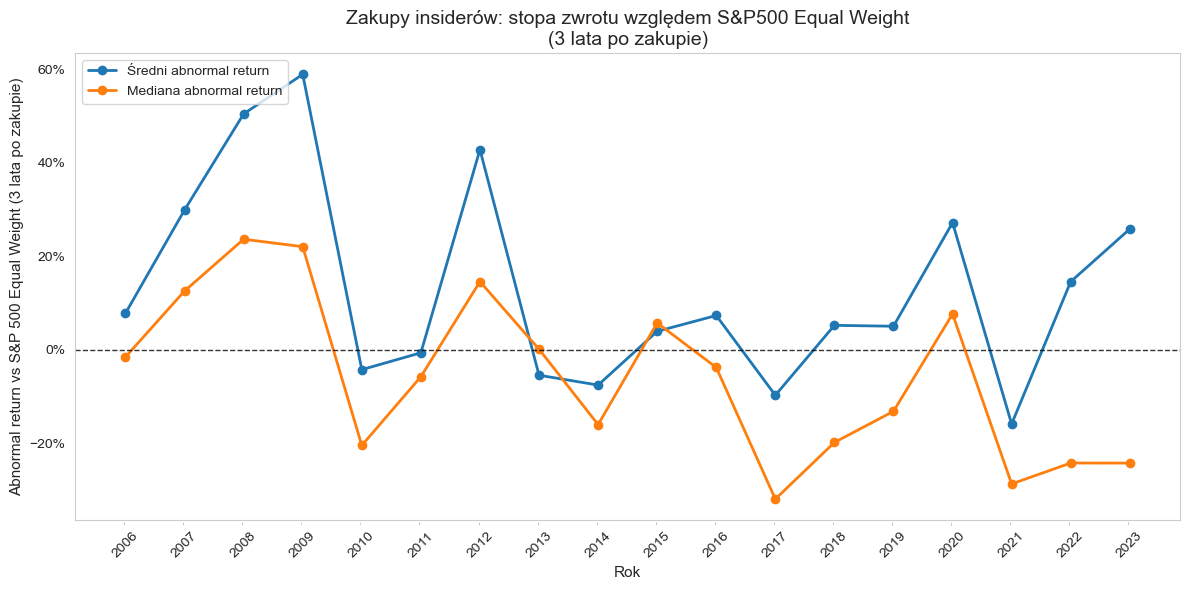

In [212]:
fig, ax = plt.subplots(figsize=(12,6))


ax.plot(
    abnormal_rsp_3y_yearly["year"],
    abnormal_rsp_3y_yearly["mean_abnormal_return"],
    color="#1f77b4",
    marker="o",
    linewidth=2,
    label="Średni abnormal return"
)


ax.plot(
    abnormal_rsp_3y_yearly["year"],
    abnormal_rsp_3y_yearly["median_abnormal_return"],
    color="#ff7f0e",
    marker="o",
    linewidth=2,
    label="Mediana abnormal return"
)


# poziom 0
ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.8
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.set_ylabel(
    "Abnormal return vs S&P 500 Equal Weight (3 lata po zakupie)",
    fontsize=11
)


ax.set_xlabel(
    "Rok",
    fontsize=11
)


ax.set_title(
    "Zakupy insiderów: stopa zwrotu względem S&P500 Equal Weight\n"
    "(3 lata po zakupie)",
    fontsize=14
)


ax.set_xticks(
    abnormal_rsp_3y_yearly["year"]
)


ax.tick_params(
    axis="x",
    rotation=45
)


# liczba obserwacji
for x, n in zip(
    abnormal_rsp_3y_yearly["year"],
    abnormal_rsp_3y_yearly["n_obs"]
):
    ax.text(
        x,
        ax.get_ylim()[0],
        f"n={n}",
        ha="center",
        va="top",
        fontsize=0,
        color="gray",
        rotation=90
    )


ax.legend(
    loc="upper left"
)


ax.grid(False)


plt.tight_layout()
plt.show()

In [214]:
summary_3y = pd.DataFrame({
    "Benchmark": [
        "Brak benchmarku",
        "S&P500 cap-weighted",
        "S&P500 equal-weighted (RSP)"
    ],

    "Średnia stopa zwrotu / AR": [
        df_rsp_3y_clean["return_3y_w"].mean(),
        df_market_3y_clean["abnormal_return_3y"].mean(),
        df_rsp_3y_clean["abnormal_return_rsp_3y"].mean()
    ],

    "Mediana": [
        df_rsp_3y_clean["return_3y_w"].median(),
        df_market_3y_clean["abnormal_return_3y"].median(),
        df_rsp_3y_clean["abnormal_return_rsp_3y"].median()
    ],

    "Hit rate": [
        (df_rsp_3y_clean["return_3y_w"] > 0).mean(),
        (df_market_3y_clean["abnormal_return_3y"] > 0).mean(),
        (df_rsp_3y_clean["abnormal_return_rsp_3y"] > 0).mean()
    ],

    "N": [
        len(df_rsp_3y_clean),
        len(df_market_3y_clean),
        len(df_rsp_3y_clean)
    ]
})


summary_3y

NameError: name 'df_market_3y_clean' is not defined

In [216]:
df_market_3y_clean = df_market_3y.dropna(
    subset=[
        "return_3y_w",
        "sp500_return_3y",
        "abnormal_return_3y"
    ]
)

In [218]:
summary_3y = pd.DataFrame({
    "Benchmark": [
        "Brak benchmarku",
        "S&P500 cap-weighted",
        "S&P500 equal-weighted (RSP)"
    ],

    "Średnia stopa zwrotu / AR": [
        df_rsp_3y_clean["return_3y_w"].mean(),
        df_market_3y_clean["abnormal_return_3y"].mean(),
        df_rsp_3y_clean["abnormal_return_rsp_3y"].mean()
    ],

    "Mediana": [
        df_rsp_3y_clean["return_3y_w"].median(),
        df_market_3y_clean["abnormal_return_3y"].median(),
        df_rsp_3y_clean["abnormal_return_rsp_3y"].median()
    ],

    "Hit rate": [
        (df_rsp_3y_clean["return_3y_w"] > 0).mean(),
        (df_market_3y_clean["abnormal_return_3y"] > 0).mean(),
        (df_rsp_3y_clean["abnormal_return_rsp_3y"] > 0).mean()
    ],

    "N": [
        len(df_rsp_3y_clean),
        len(df_market_3y_clean),
        len(df_rsp_3y_clean)
    ]
})


summary_3y

,Benchmark,Średnia stopa zwrotu / AR,Mediana,Hit rate,N
0,Brak benchmarku,44.336098,23.782158,0.635198,13262
1,S&P500 cap-weighted,8.454912,-8.177724,0.449119,13217
2,S&P500 equal-weighted (RSP),11.947390,-6.777666,0.459584,13262


In [220]:
df = df.sort_values(
    [
        "ticker",
        "date"
    ]
).copy()

In [222]:
cluster_flag = []

for ticker, group in df.groupby("ticker"):

    group = group.sort_values("date")

    dates = group["date"].tolist()
    names = group["name"].tolist()

    flags = []

    for i in range(len(group)):

        current_date = dates[i]
        current_name = names[i]

        window = group[
            (group["date"] >= current_date - pd.Timedelta(days=5)) &
            (group["date"] <= current_date + pd.Timedelta(days=5))
        ]

        other_insiders = (
            window[
                window["name"] != current_name
            ]["name"]
            .nunique()
        )

        flags.append(
            other_insiders >= 1
        )

    cluster_flag.extend(flags)

In [224]:
df["cluster_buy"] = np.where(
    cluster_flag,
    "Yes",
    "No"
)

In [226]:
df["cluster_buy"].value_counts()

cluster_buy
No     12017
Yes     5132
Name: count, dtype: int64

In [228]:
cluster_stats_3y = df.groupby(
    "cluster_buy"
).agg(
    n_obs=("return_3y_w", "count"),
    mean_return=("return_3y_w", "mean"),
    median_return=("return_3y_w", "median"),
    hit_rate=(
        "return_3y_w",
        lambda x: (x.dropna() > 0).mean()
    )
)

cluster_stats_3y

,n_obs,mean_return,median_return,hit_rate
cluster_buy,,,,
No,9303,44.758599,21.409423,0.628829
Yes,3959,43.343291,29.807659,0.650164


In [234]:
df["date"] = pd.to_datetime(df["date"])

cluster_events = []

for ticker, company_df in df.groupby("ticker"):

    company_df = company_df.sort_values("date").copy()

    # Jeden rekord na dzień (potrzebny tylko do iteracji po dniach)
    trading_days = (
        company_df["date"]
        .drop_duplicates()
        .sort_values()
    )

    cluster_active = False

    for current_date in trading_days:

        # okno 5 dni wstecz
        window = company_df[
            (company_df["date"] >= current_date - pd.Timedelta(days=5)) &
            (company_df["date"] <= current_date)
        ]

        n_unique_insiders = window["name"].nunique()

        if n_unique_insiders >= 2:

            # tylko pierwszy dzień klastra
            if not cluster_active:

                cluster_active = True

                signal_day = company_df[
                    company_df["date"] == current_date
                ]

                # pierwszy rekord z dnia - potrzebny do pobrania stóp zwrotu
                signal = signal_day.iloc[0]

                cluster_events.append({

                    "ticker": ticker,
                    "company": signal["company"],
                    "signal_date": current_date,

                    # siła klastra
                    "cluster_size": n_unique_insiders,
                    "transactions_in_window": len(window),
                    "insiders_on_signal_day": signal_day["name"].nunique(),

                    # wartość zakupów w dniu sygnału
                    "value_usd_signal_day": signal_day["value_usd"].sum(),

                    # stopy zwrotu
                    "return_3y_w": signal["return_3y_w"],

                    # ceny
                    "entry_price": signal["entry_price"],
                    "price_3y_after": signal["price_3y_after"]
                })

        else:
            # klaster się zakończył
            cluster_active = False


cluster_events = pd.DataFrame(cluster_events)

In [236]:
len(cluster_events)

1414

In [238]:
cluster_stats_3y = cluster_events.agg(
    n_obs=("return_3y_w", "count"),
    mean_return=("return_3y_w", "mean"),
    median_return=("return_3y_w", "median"),
    std_return=("return_3y_w", "std"),
    hit_rate=("return_3y_w", lambda x: (x.dropna() > 0).mean())
)

cluster_stats_3y = pd.DataFrame(cluster_stats_3y).T

cluster_stats_3y["hit_rate"] *= 100

cluster_stats_3y.round(2)

,n_obs,mean_return,median_return,std_return,hit_rate
return_3y_w,1100.0,43.59,27.11,115.82,63.64


In [240]:
comparison_3y = pd.DataFrame({
    "Strategia": [
        "Wszystkie zakupy",
        "Cluster buy"
    ],
    "N": [
        df["return_3y_w"].count(),
        cluster_events["return_3y_w"].count()
    ],
    "Średnia (%)": [
        df["return_3y_w"].mean(),
        cluster_events["return_3y_w"].mean()
    ],
    "Mediana (%)": [
        df["return_3y_w"].median(),
        cluster_events["return_3y_w"].median()
    ],
    "Odch. std.": [
        df["return_3y_w"].std(),
        cluster_events["return_3y_w"].std()
    ],
    "Hit rate (%)": [
        (df["return_3y_w"].dropna() > 0).mean() * 100,
        (cluster_events["return_3y_w"].dropna() > 0).mean() * 100
    ]
}).round(2)

comparison_3y

,Strategia,N,Średnia (%),Mediana (%),Odch. std.,Hit rate (%)
0,Wszystkie zakupy,13262,44.34,23.78,115.41,63.52
1,Cluster buy,1100,43.59,27.11,115.82,63.64
